In [5]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

### Mamba Model for timeserries prediction

In [6]:
# -----------------------------------------------------------------------------
# 1. Data Loading & Generation (Same as Mamba)
# -----------------------------------------------------------------------------
from torch.utils.data import DataLoader, Dataset

def generate_synthetic_power_data(days=365, interval_min=15):
    """Generates synthetic power usage data."""
    # f(t) = sin(t) + 0.5sin(t/7) + noise + 10
    # noise is Gaussian noise, mean = 0, std = 0.1
    total_steps = int(days * 24 * 60 / interval_min)
    t = np.linspace(0, days * 2 * np.pi, total_steps)
    daily = np.sin(t) 
    weekly = 0.5 * np.sin(t / 7)
    noise = np.random.normal(0, 0.1, total_steps)
    power = daily + weekly + noise + 10.0
    power = (power - power.min()) / (power.max() - power.min())
    return torch.tensor(power, dtype=torch.float32).unsqueeze(-1)

# ==========================================================
# Real Power PV generated power data.
import os
import pandas as pd
# read the data for PVOD
abs_path = os.path.abspath("../PVODdatasets_v1")
metadata_path = os.path.join(abs_path, "metadata.csv")
metaData = pd.read_csv(metadata_path)

def get_station_metadata(station_num, df):
    """
    Retrieves metadata for a specific station number.
    
    Args:
        station_num (int or str): The station number (e.g., 5 or '05').
        df (pd.DataFrame): The source dataframe (metaData).
        
    Returns:
        dict: A dictionary containing all processed metadata for the station.
    """
    
    # 1. Format the station ID (e.g., 5 -> 'station05')
    # zfill(2) ensures '5' becomes '05', but leaves '10' as '10'
    station_id_str = f"station{str(station_num).zfill(2)}"
    
    # 2. Filter the dataframe
    station_row = df[df['Station_ID'] == station_id_str]
    
    # Check if station exists to prevent errors
    if station_row.empty:
        return f"Error: Station ID {station_id_str} not found."
    
    # Get the single row as a Series for easy access
    row = station_row.iloc[0]

    # --- Helper to parse the "Key:Value\nKey:Value" strings ---
    def parse_kv_string(text_block):
        data = {}
        if isinstance(text_block, str):
            for item in text_block.split('\n'):
                if ':' in item:
                    k, v = item.split(':', 1)
                    data[k.strip()] = v.strip()
        return data

    # 3. Parse complex columns
    module_items = parse_kv_string(row['Module'])
    inverter_items = parse_kv_string(row['Inverters'])

    # 4. Build the final dictionary
    # Note: We use .get() for the parsed items to safely handle missing keys
    result_dict = {
        'Station_ID': station_id_str, # Added ID for reference
        'Capacity': row['Capacity'],
        'pv_tech': row['PV_Technology'],
        'Panel_Size': row['Panel_Size'],
        
        # Parsed Module Items
        'Module_Pmax': module_items.get('Pmax'),
        'Module_Vmpp': module_items.get('Vmpp'),
        'Module_Impp': module_items.get('Impp'),
        
        # Parsed Inverter Items
        'Inverter_Max_DC_input': inverter_items.get('Max. DC input'),
        'Inverter_Max_DC_voltage': inverter_items.get('Max. DC voltage'),
        'Inverter_Max_DC_current': inverter_items.get('Max. DC current'),
        'Inverter_Max_DC_Rated_power': inverter_items.get('Rated power'),
        
        'Layout': row['Layout'],
        'Panel_Number': row['Panel_Number'],
        'Array_Tilt': row['Array_Tilt'],
        'Longitude': row['Longitude'],
        'Latitude': row['Latitude']
    }
    
    return result_dict



import pandas as pd
import pvlib
from pvlib import location, pvsystem, modelchain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS
import re
import numpy as np

def calculate_clearsky_index(metadata, df):
    """
    Calculates Clear Sky Power (P_CLR) and PV Clear Sky Index (K_PV).
    Scales the simulation to the full station capacity and handles DataFrame outputs safely.
    """
    
    # ---------------------------------------------------------
    # 1. PARSE METADATA
    # ---------------------------------------------------------
    station_id = metadata.get('Station_ID', 'Unknown')
    print(f"Processing Station: {station_id}")
    
    def extract_num(s):
        if isinstance(s, (int, float)): return float(s)
        match = re.search(r"[-+]?\d*\.\d+|\d+", str(s))
        return float(match.group()) if match else 0.0

    # Parse Layout
    layout_str = metadata.get('Layout', '')
    mod_per_string = 20 # default
    str_per_inv = 100   # default
    
    if 'modules per string' in layout_str:
        try:
            mod_per_string = int(extract_num(layout_str.split('modules per string:')[1].split('\n')[0]))
            str_per_inv = int(extract_num(layout_str.split('strings per inverter:')[1]))
        except:
            print("Warning: Could not parse Layout string, using defaults.")

    # Parse Tilt & Azimuth
    tilt_str = metadata.get('Array_Tilt', 'South 30')
    tilt = extract_num(tilt_str)
    
    azimuth = 180 
    if 'North' in tilt_str: azimuth = 0
    elif 'East' in tilt_str: azimuth = 90
    elif 'West' in tilt_str: azimuth = 270

    # ---------------------------------------------------------
    # 2. SETUP LOCATION & WEATHER
    # ---------------------------------------------------------
    # Copy df to avoid SettingWithCopy warnings on the original
    df = df.copy()
    
    if 'date_time' in df.columns:
        df = df.set_index('date_time')
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
        
    # Handle duplicates
    if df.index.duplicated().any():
        df = df[~df.index.duplicated(keep='first')]

    lat = metadata.get('Latitude', 38.0)
    lon = metadata.get('Longitude', 114.0)
    
    site_location = location.Location(lat, lon, tz='UTC') 

    print("Generating clear sky irradiance data...")
    clearsky_weather = site_location.get_clearsky(df.index, model='ineichen')

    # ---------------------------------------------------------
    # 3. DEFINE PV SYSTEM (Using PVWatts Inverter Model)
    # ---------------------------------------------------------
    temp_params = TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']

    # --- Module Parameters ---
    sandia_modules = pvsystem.retrieve_sam('SandiaMod')
    module_template = sandia_modules.columns[0]
    module_params = sandia_modules[module_template].copy()
    
    # Overwrite electrical specs from metadata
    module_params['Impo'] = extract_num(metadata.get('Module_Impp', 8.0))
    module_params['Vmpo'] = extract_num(metadata.get('Module_Vmpp', 30.0))
    module_params['Isco'] = module_params['Impo'] * 1.05 
    module_params['Voco'] = module_params['Vmpo'] * 1.2
    
    # --- Inverter Parameters & Scaling ---
    panel_watts = extract_num(metadata.get('Module_Pmax', 300))
    
    # DC Capacity of ONE inverter block (Watts)
    block_dc_capacity_watts = (mod_per_string * str_per_inv) * panel_watts
    
    # Station Total Capacity (Watts)
    station_capacity_watts = extract_num(metadata.get('Capacity', 0)) * 1000 
    
    # Calculate Scaling Factor (How many such blocks make up the station?)
    if block_dc_capacity_watts > 0 and station_capacity_watts > 0:
        scaling_factor = station_capacity_watts / block_dc_capacity_watts
    else:
        scaling_factor = 1.0
        
    print(f"Station Capacity: {station_capacity_watts/1e6:.2f} MW")
    print(f"Modeled Block Capacity: {block_dc_capacity_watts/1e6:.2f} MW")
    print(f"Scaling Factor: {scaling_factor:.2f}x")

    inverter_params = {
        'pdc0': block_dc_capacity_watts, 
        'eta_inv_nom': 0.96 
    }

    system = pvsystem.PVSystem(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        module_parameters=module_params,
        inverter_parameters=inverter_params,
        modules_per_string=mod_per_string,
        strings_per_inverter=str_per_inv,
        temperature_model_parameters=temp_params
    )

    # ---------------------------------------------------------
    # 4. RUN MODEL CHAIN
    # ---------------------------------------------------------
    mc = modelchain.ModelChain(
        system, 
        site_location,
        transposition_model="perez",
        solar_position_method="nrel_numpy",
        aoi_model="physical",
        spectral_model="no_loss",
        ac_model='pvwatts'
    )

    print("Running simulation...")
    try:
        mc.run_model(clearsky_weather)
    except Exception as e:
        print(f"Simulation failed: {e}")
        return df

    # ---------------------------------------------------------
    # 5. PROCESS RESULTS (Fixing ValueError)
    # ---------------------------------------------------------
    ac_output = mc.results.ac
    
    # FIX: Ensure output is a Series, summing if it's a DataFrame
    if isinstance(ac_output, pd.DataFrame):
        ac_output = ac_output.sum(axis=1)
        
    # Scale to full station capacity
    p_clr_watts = ac_output * scaling_factor
    
    # Convert to MW
    p_clr_mw = p_clr_watts / 1_000_000
    p_clr_mw = p_clr_mw.fillna(0).clip(lower=0)
    
    # Assign to DataFrame
    df['P_CLR'] = p_clr_mw
    
    # Calculate K_PV (Clear Sky Index)
    if 'power' in df.columns:
        # Filter small P_CLR values to avoid division by zero artifacts
        df['K_PV'] = np.where(df['P_CLR'] > 0.1, df['power'] / df['P_CLR'], 0.0)
    else:
        print("Warning: 'power' column not found. K_PV not calculated.")

    return df



station07_path = os.path.join(abs_path, "station07.csv")
station07_data = pd.read_csv(station07_path)


station07_metaData = get_station_metadata(7, metaData)
station07_data = pd.read_csv(station07_path)


# 3. Run Calculation
station07_df = calculate_clearsky_index(station07_metaData, station07_data)



# ==========================================================

class MultiStepDataset(Dataset):
    """
    Multistep Dataset Preparation.
    """
    def __init__(self, X, y, seq_len=96, pred_len=96):
        self.X = X
        self.y = y
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        # We need to ensure we have enough data for Input + Output
        return len(self.X) - self.seq_len - self.pred_len

    def __getitem__(self, i):
        # returning torch tensors of [i:seq_length] as input and [i+seq_length:i+seq_length+pred_len] as output
        # --- Input Sequence (Today) ---
        # Shape: [seq_len, Features] (e.g., 96, 5)
        x_seq = self.X[i : i + self.seq_len]
        
        # --- Target Sequence (Tomorrow) ---
        # We want the PV values (Column 0 usually) for the NEXT 'pred_len' steps
        # Shape: [pred_len] (e.g., 96)
        y_start = i + self.seq_len
        y_seq = self.y[y_start : y_start + self.pred_len] 
        
        return torch.tensor(x_seq), torch.tensor(y_seq)

Processing Station: station07
Generating clear sky irradiance data...
Station Capacity: 20.00 MW
Modeled Block Capacity: 0.50 MW
Scaling Factor: 40.00x
Running simulation...


In [7]:
station07_df.columns

Index(['nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity',
       'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'lmd_totalirrad',
       'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure',
       'lmd_winddirection', 'lmd_windspeed', 'power', 'P_CLR', 'K_PV'],
      dtype='object')

In [8]:
# Adding cyclic featres 


from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import TimeSeriesSplit


# --- A. Feature Engineering (Cyclic Time) ---
def prepare_features(df):
    data = df.copy()
    
    # 1. Cyclic Encoding for Hour (0-23)
    # This helps the model know that 23:00 is close to 00:00
    data['hour_sin'] = np.sin(2 * np.pi * data.index.hour / 24)
    data['hour_cos'] = np.cos(2 * np.pi * data.index.hour / 24)
    
    # 2. Cyclic Encoding for Day of Year (1-365)
    # This captures seasonality (Summer vs Winter)
    data['day_sin'] = np.sin(2 * np.pi * data.index.dayofyear / 365)
    data['day_cos'] = np.cos(2 * np.pi * data.index.dayofyear / 365)
    
    # Define Inputs (Features) and Output (Target)
    # Input: [PV value, Hour_Sin, Hour_Cos, Day_Sin, Day_Cos] -> 5 Features
    feature_cols = ['K_PV', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']
    
    X = data[feature_cols].values.astype(np.float32)
    y = data['K_PV'].values.astype(np.float32)
    
    return X, y

# Apply to your dataframe
X_all, y_all = prepare_features(station07_df)

print(f"Features Shape: {X_all.shape}") # Should be (N_samples, 5)



Features Shape: (32928, 5)


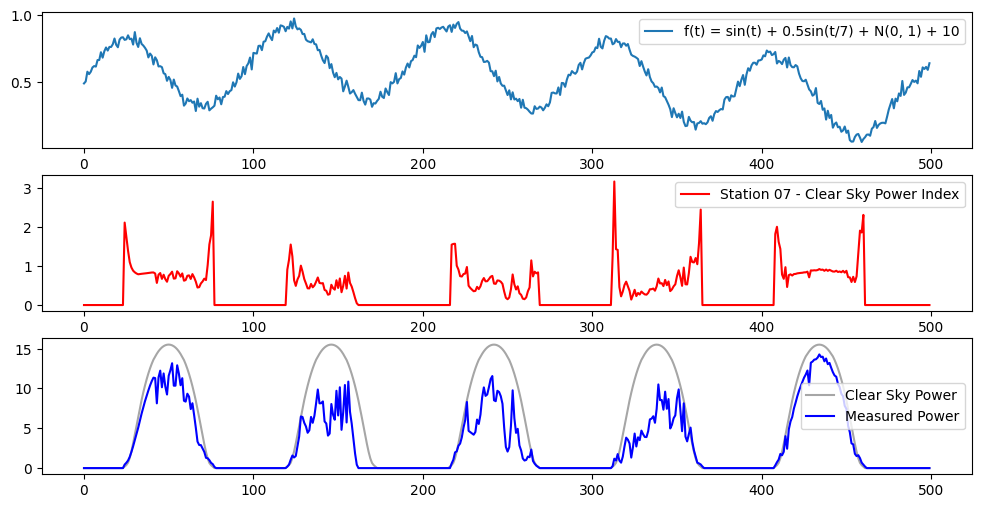

In [9]:
synthitic_power = generate_synthetic_power_data().numpy()
t = np.linspace(0, synthitic_power.shape[0], synthitic_power.shape[0])
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(t[:500], synthitic_power[:500], label='f(t) = sin(t) + 0.5sin(t/7) + N(0, 1) + 10')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t[:500], station07_df['K_PV'][:500], label='Station 07 - Clear Sky Power Index', color='red')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t[:500], station07_df['P_CLR'][:500], label='Clear Sky Power', color='black', alpha=0.35)

plt.plot(t[:500], station07_df['power'][:500], label='Measured Power', color='blue')
plt.legend()

plt.show()

----

## Vanilla RNN and LSTM In prediction, Multistep prediction is used... Autoregressive can be.

In [6]:
class RevIN(nn.Module):
    def __init__(self, num_features: int, eps=1e-5, affine=True):
        """
        Reversible Instance Normalization for Time Series.
        
        Args:
            num_features: Number of input channels (C).
            eps: Small constant for numerical stability.
            affine: If True, learns a minimal W and b to rescale data after norm.
        """
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine

        # Learnable parameters (like Batch Norm, but applied after the denorm step usually, 
        # or used to tweak the normalized distribution). 
        # In standard RevIN, we usually rely on the statistics, but affine weights 
        # allow the model to learn a "standard" scale it prefers.
        if self.affine:
            self.affine_weight = nn.Parameter(torch.ones(1, 1, num_features))
            self.affine_bias = nn.Parameter(torch.zeros(1, 1, num_features))

    def _get_statistics(self, x):
        # x shape: [Batch, Length, Channels]
        # We calculate stats across the Length dimension (dim=1)
        # We want a separate mean/std for every sample and every channel.
        # Result shape: [Batch, 1, Channels]
        
        self.mean = torch.mean(x, dim=1, keepdim=True).detach() 
        self.stdev = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + self.eps).detach()

    def forward(self, x, mode: str):
        if mode == 'norm':
            self._get_statistics(x)
            x = (x - self.mean) / self.stdev
            
            if self.affine:
                x = x * self.affine_weight + self.affine_bias
            return x
            
        elif mode == 'denorm':
            if self.affine:
                x = (x - self.affine_bias) / (self.affine_weight + self.eps)
            
            # Restore the original scale using the stored statistics
            x = x * self.stdev + self.mean
            return x
        else:
            raise NotImplementedError(f"Mode {mode} not implemented. Use 'norm' or 'denorm'.")

class RNN(nn.Module):
    def __init__(self, input_size: int, output_size: int = 1, hidden_size: int = 128, n_layers: int = 2):
        super().__init__()
        self.input_size = input_size # features 
        self.hidden_size = hidden_size # Projection
        self.n_layers = n_layers
        self.output_size = output_size
        
        # 1. RevIN (Sanitizer)
        # Note: If input_size != output_size (e.g. Multivariate), we handle denorm carefully below.
        self.revin = RevIN(num_features=input_size, affine=False)
        
        # 2. RNN Backbone
        self.rnn = nn.RNN(input_size, hidden_size, n_layers, batch_first=True)
        
        # 3. Projection Head
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: [Batch, Length, Input_Features]
        
        # --- Step 1: Normalize ---
        x = self.revin(x, mode='norm')
        
        # --- Step 2: Backbone ---
        h0 = torch.zeros(self.n_layers, x.size(0), self.hidden_size).to(x.device)
        
        # out shape: [Batch, Length, Hidden_Size]
        out, _ = self.rnn(x, h0)
        
        # --- FIX: Slice the Last Time Step ---
        # We only care about the prediction after seeing the FULL sequence.
        # We take the last element in the 'Length' dimension (-1).
        out = out[:, -1, :]  
        # New shape: [Batch, Hidden_Size]
        
        # --- Step 3: Projection ---
        out = self.fc(out)
        # Final shape: [Batch, Output_Size] -> Matches your Target shape!
        
        # --- Step 4: Denormalize (Conditional) ---
        # CAUTION: We can only auto-denormalize if the Input Features == Output Features.
        # If Input has 5 features (PV + Time) and Output has 1 (PV), RevIN cannot map them back automatically.
        if self.input_size == self.output_size:
            out = self.revin(out, mode='denorm')
        
        return out

class MultiStepRNN(nn.Module):
    def __init__(self, input_size, pred_len=96, hidden_size=128, n_layers=2):
        super().__init__()
        self.input_size = input_size
        self.pred_len = pred_len
        self.hidden_size = hidden_size
        self.n_layers = n_layers
        
        # 1. Backbone
        self.rnn = nn.RNN(input_size, hidden_size, n_layers, batch_first=True)
        
        # 2. Projection Head (Vector Output)
        # Maps 128 hidden features -> 96 future PV values directly
        self.fc = nn.Linear(hidden_size, pred_len)

    def forward(self, x):
        # x shape: [Batch, Seq_Len, Features]
        
        # Initialize hidden state
        h0 = torch.zeros(self.n_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Run RNN
        # out shape: [Batch, Seq_Len, Hidden_Size]
        out, _ = self.rnn(x, h0)
        
        # Slice: Take ONLY the last time step's summary
        # This summary "contains" the info for the whole past day
        last_step_out = out[:, -1, :] # Shape: [Batch, Hidden_Size]
        
        # Project: Predict the entire future vector at once
        prediction = self.fc(last_step_out) 
        # Final Shape: [Batch, Pred_Len] -> [32, 96]
        
        return prediction

class LSTM(nn.Module):
    def __init__(self, input_size: int, output_size: int = 1, hidden_size: int = 128, n_layers: int = 2):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.n_layers = n_layers
        self.output_size = output_size
        
        # 1. RevIN (Sanitizer) - NOTE: If input features != output features, 
        # RevIN can be tricky. For now, we will disable it or handle it carefully.
        # If you are using Cyclic features (Input=5) and predicting PV (Output=1),
        # standard RevIN might error out if it expects input_dim == output_dim.
        # For this debug fix, I will comment it out to get your code running.
        # self.revin = RevIN(num_features=input_size, affine=True) 
        
        # 2. LSTM Backbone
        self.lstm = nn.LSTM(input_size, hidden_size, n_layers, batch_first=True)
        
        # 3. Projection Head
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: [Batch, Length, Features]
        
        # --- Step 1: Normalize (Skipping RevIN for now to prevent Dim mismatch) ---
        # x = self.revin(x, mode='norm')
        
        # --- Step 2: Backbone ---
        h0 = torch.zeros(self.n_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.n_layers, x.size(0), self.hidden_size).to(x.device) 
        
        # out shape: [Batch, Length, Hidden_Size]
        out, _ = self.lstm(x, (h0, c0)) 
        
        # --- CRITICAL FIX IS HERE ---
        # We only care about the LAST time step for the prediction
        # Slice: [All Batches, Last Time Step, All Hidden Features]
        out = out[:, -1, :]  # Shape becomes [Batch, Hidden_Size]
        
        # --- Step 3: Projection ---
        out = self.fc(out) # Shape becomes [Batch, Output_Size] -> [32, 1]
        
        # --- Step 4: Denormalize ---
        # out = self.revin(out, mode='denorm')
        
        return out

In [7]:
# --- Configuration ---
SEQ_LEN = 288   # Input: Past 24 hours
PRED_LEN = 96  # Output: Future 24 hours
BATCH_SIZE = 32
LR = 0.001
EPOCHS = 50
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- 1. Prepare Data (Using the Rolling Split / Data Prep from before) ---
# Assuming X_all (Features) and y_all (PV Target) are ready
train_size = int(len(X_all) * 0.8)

# Split Data
X_train, y_train = X_all[:train_size], y_all[:train_size]
X_val, y_val = X_all[train_size:], y_all[train_size:]

# Create Datasets
train_ds = MultiStepDataset(X_train, y_train, SEQ_LEN, PRED_LEN)
val_ds = MultiStepDataset(X_val, y_val, SEQ_LEN, PRED_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

Starting Multi-Step Training...
Epoch 5 | Train Loss: 0.03916 | Val Loss: 0.17354
Epoch 10 | Train Loss: 0.03671 | Val Loss: 0.15020
Epoch 15 | Train Loss: 0.03596 | Val Loss: 0.16219
Epoch 20 | Train Loss: 0.03511 | Val Loss: 0.16473
Epoch 25 | Train Loss: 0.03396 | Val Loss: 0.16202
Epoch 30 | Train Loss: 0.03420 | Val Loss: 0.17189
Epoch 35 | Train Loss: 0.03402 | Val Loss: 0.14961
Epoch 40 | Train Loss: 0.03467 | Val Loss: 0.16640
Epoch 45 | Train Loss: 0.03406 | Val Loss: 0.15211
Epoch 50 | Train Loss: 0.03332 | Val Loss: 0.15357


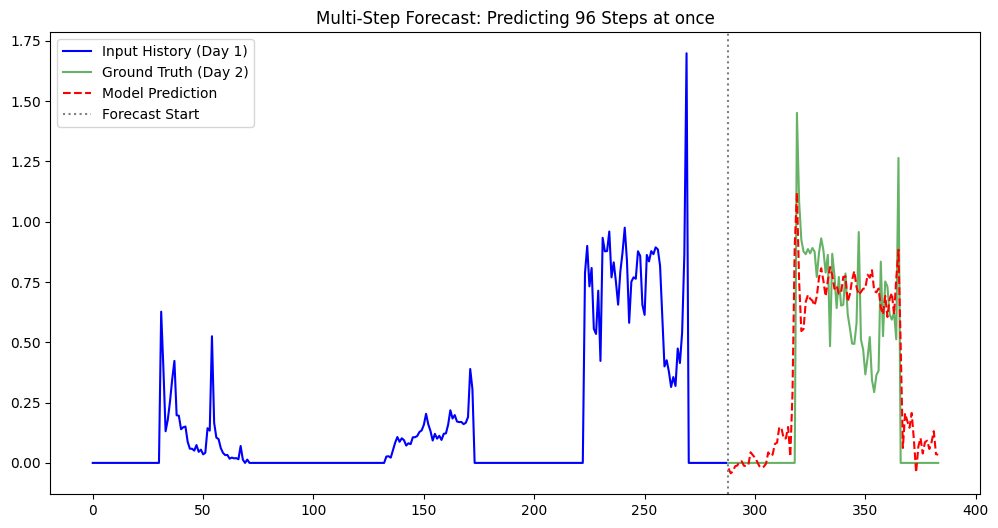

Starting 10-Day Forecast...


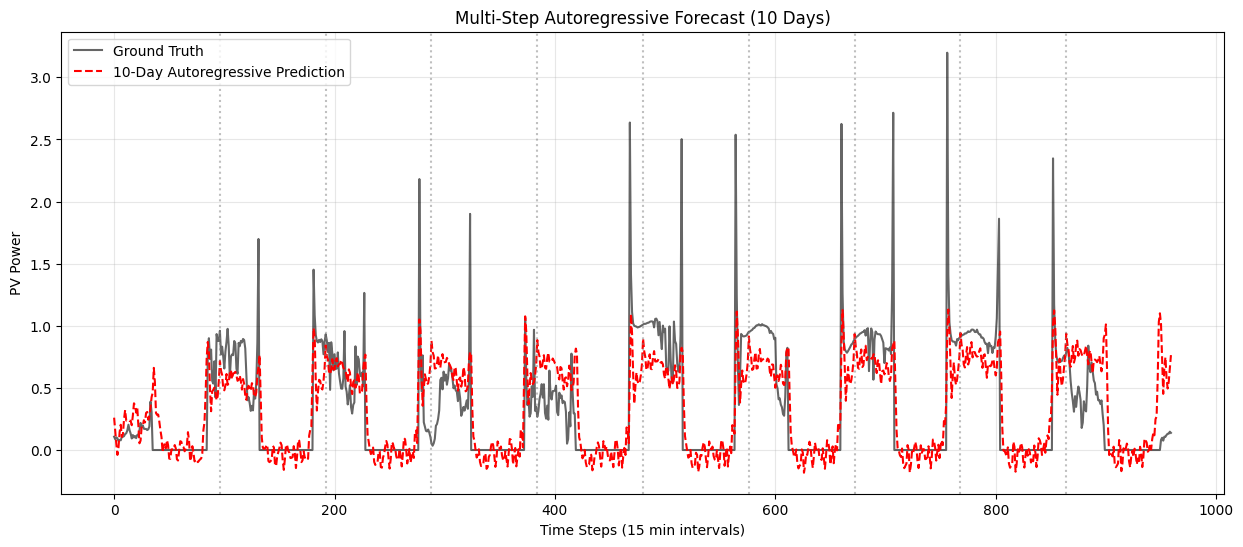

In [8]:


# --- 2. Initialize Model ---
# input_size=5 (PV + 4 Time Features)
model = MultiStepRNN(input_size=5, pred_len=PRED_LEN, hidden_size=128, n_layers=2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

# --- 3. Train Loop ---
print("Starting Multi-Step Training...")
for epoch in range(EPOCHS):
    model.train()
    train_loss = []
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer.zero_grad()
        preds = model(inputs) # Output: [32, 96]
        
        loss = criterion(preds, targets) # Compare [32, 96] vs [32, 96]
        loss.backward()
        optimizer.step()
        train_loss.append(loss.item())

    # Validation
    model.eval()
    val_loss = []
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            preds = model(inputs)
            loss = criterion(preds, targets)
            val_loss.append(loss.item())
            
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1} | Train Loss: {np.mean(train_loss):.5f} | Val Loss: {np.mean(val_loss):.5f}")

# --- 4. Visualization (The "Day Ahead" Plot) ---
def plot_multistep_forecast(model, dataset, idx=0):
    model.eval()
    inputs, target = dataset[idx]
    
    # Add batch dim for model
    input_tensor = inputs.unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        prediction = model(input_tensor).cpu().numpy()[0] # Shape [96]
        
    # Prepare X-axis
    input_range = range(0, SEQ_LEN)
    output_range = range(SEQ_LEN, SEQ_LEN + PRED_LEN)
    
    plt.figure(figsize=(12, 6))
    
    # 1. Plot Input (History) - Use only the PV column (index 0)
    plt.plot(input_range, inputs[:, 0], label='Input History (Day 1)', color='blue')
    
    # 2. Plot Ground Truth (Target)
    plt.plot(output_range, target, label='Ground Truth (Day 2)', color='green', alpha=0.6)
    
    # 3. Plot Prediction
    plt.plot(output_range, prediction, label='Model Prediction', color='red', linestyle='--')
    
    plt.axvline(x=SEQ_LEN, color='gray', linestyle=':', label='Forecast Start')
    plt.title(f"Multi-Step Forecast: Predicting {PRED_LEN} Steps at once")
    plt.legend()
    plt.show()

# Visualize a random sample from validation
plot_multistep_forecast(model, val_ds, idx=150)

# ======================
def forecast_multi_day(model, dataset, start_idx=0, days_ahead=5, device='cpu'):
    """
    Performs Block Autoregression.
    Input: Real Day 0
    Output: Predict Day 1 -> Feed back -> Predict Day 2 -> Feed back ...
    """
    model.eval()
    model.to(device)
    
    # Constants
    SEQ_LEN = dataset.seq_len  # 96
    PRED_LEN = dataset.pred_len # 96
    TOTAL_STEPS = days_ahead * PRED_LEN
    
    # --- 1. Get Initial Input (Day 0) ---
    # Input Shape: (1, 96, 5)
    initial_input, _ = dataset[start_idx]
    current_input = initial_input.unsqueeze(0).to(device)
    
    # We need to know where we are in the real timeline to grab Time Features
    # The first prediction starts AFTER the input sequence
    current_time_idx = start_idx + SEQ_LEN 
    
    all_predictions = []
    
    print(f"Starting {days_ahead}-Day Forecast...")
    
    with torch.no_grad():
        for day in range(days_ahead):
            # --- A. Predict the Next Block (96 steps) ---
            # Output Shape: (1, 96) - Vector of PV values
            pred_pv_block = model(current_input)
            
            # Save predictions
            pred_pv_numpy = pred_pv_block.cpu().numpy()[0] # Shape (96,)
            all_predictions.extend(pred_pv_numpy)
            
            # --- B. Prepare Input for Next Block ---
            # We need to build the input tensor for the NEXT iteration.
            # Input must be (1, 96, 5).
            # We have the 96 PV values we just predicted.
            # We need the 96 Time Features for those same timestamps.
            
            # Calculate indices for the NEXT block of time
            # We just predicted 'day', so we need time features for 'day' 
            # to feed in as history for 'day+1'.
            
            # Time features are in columns 1, 2, 3, 4 of dataset.X
            # We need the time features corresponding to the block we JUST predicted
            block_start_time = current_time_idx
            block_end_time = current_time_idx + PRED_LEN
            
            # Safety Check: Stop if we run out of data in the test set
            if block_end_time > len(dataset.X):
                print("Warning: Reached end of dataset ground truth.")
                break
            
            # Grab Time Features (Known Future)
            # Shape: (96, 4)
            next_time_features = dataset.X[block_start_time : block_end_time, 1:]
            
            # Verify shapes match before sticking them together
            # pred_pv_numpy is (96,) -> make it (96, 1)
            pred_pv_reshaped = pred_pv_numpy.reshape(-1, 1)
            
            # Concatenate [Pred_PV, Real_Time] -> Shape (96, 5)
            next_input_block = np.hstack([pred_pv_reshaped, next_time_features])
            
            # Convert to Tensor for next loop
            current_input = torch.tensor(next_input_block, dtype=torch.float32).unsqueeze(0).to(device)
            
            # Advance the time index tracker
            current_time_idx += PRED_LEN

    # --- 3. Visualization ---
    # Grab Ground Truth for the entire forecast horizon
    gt_start = start_idx + SEQ_LEN
    gt_end = gt_start + len(all_predictions)
    ground_truth = dataset.X[gt_start : gt_end, 0] # Column 0 is PV
    
    # Plot
    plt.figure(figsize=(15, 6))
    plt.plot(ground_truth, label='Ground Truth', color='black', alpha=0.6)
    plt.plot(all_predictions, label=f'{days_ahead}-Day Autoregressive Prediction', color='red', linestyle='--')
    
    # Draw vertical lines to separate days
    for i in range(1, days_ahead):
        plt.axvline(x=i*PRED_LEN, color='gray', linestyle=':', alpha=0.5)
        
    plt.title(f"Multi-Step Autoregressive Forecast ({days_ahead} Days)")
    plt.xlabel("Time Steps (15 min intervals)")
    plt.ylabel("PV Power")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- Run the Test ---
# idx=0 means start from the very beginning of the validation set
forecast_multi_day(model, val_ds, start_idx=0, days_ahead=10, device=DEVICE)

RNN --> Average Validation MSE across all folds: 0.05330
LSTM --> Average Validation MSE across all folds: 0.03674

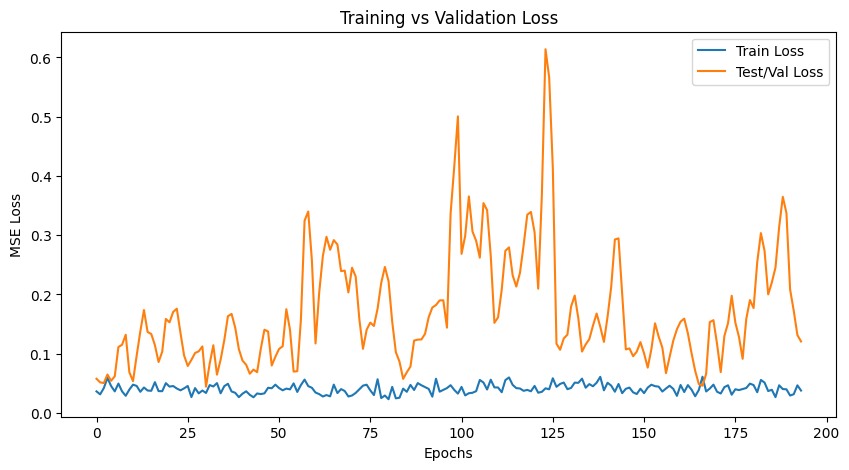

In [31]:
history = {'train_loss': train_loss[len(train_loss) - len(val_loss):], 'val_loss': val_loss}
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Test/Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

----

## PINNS

In [16]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

class NBROKMeans:
    def __init__(self, n_clusters, max_iter=300, tol=1e-4):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.centroids = None

    def _newton_raphson_update(self, cluster_points):
        """
        Conceptual Newton-Raphson update for a single centroid.
        
        In a true NBRO implementation, this function minimizes the sum of squared 
        errors for the given cluster points using the Newton-Raphson method,
        which involves calculating first and second derivatives of the objective
        function.
        
        For demonstration, this is a placeholder as the exact objective function
        for the full NBRO model is complex. The standard k-means uses the mean, 
        which is the global optimum for the sum of squares objective. 
        A true NBRO implementation is used to optimize cluster numbers or hyperparameters 
        dynamically, not just a single centroid's location in the typical K-means step.
        """
        if len(cluster_points) == 0:
            return None
        
        # Standard k-means update (mean calculation)
        new_centroid = np.mean(cluster_points, axis=0)
        return new_centroid
        
        # A full implementation would involve defining the objective function's 
        # gradient and Hessian and applying the update rule:
        # x_next = x - inv(Hessian(x)) * Gradient(x)
        # This is highly application-specific and complex for a general clustering problem.

    def fit(self, X):
        # Step 1: K-means++ Initialization
        # We use sklearn's robust implementation for smart initialization
        kmeans_plus = KMeans(n_clusters=self.n_clusters, init='k-means++', n_init=1, max_iter=1, random_state=0)
        kmeans_plus.fit(X)
        self.centroids = kmeans_plus.cluster_centers_

        for iteration in range(self.max_iter):
            old_centroids = np.copy(self.centroids)

            # Step 2: Assign points to the closest centroid (E-step)
            # Returns cluster indices for each point
            labels, _ = pairwise_distances_argmin_min(X, self.centroids)
            
            # Step 3: Update centroids using the (conceptual) NBRO update
            for i in range(self.n_clusters):
                # Get points belonging to the current cluster
                cluster_points = X[labels == i]
                if len(cluster_points) > 0:
                    # Use the conceptual Newton-Raphson update function
                    self.centroids[i] = self._newton_raphson_update(cluster_points)
            
            # Step 4: Check for convergence
            # If centroids do not move significantly, stop
            if np.all(np.abs(old_centroids - self.centroids) < self.tol):
                print(f"NBRO-KMeans++ converged after {iteration + 1} iterations.")
                break
        else:
            print(f"NBRO-KMeans++ did not converge within {self.max_iter} iterations.")
        
        return self

    def predict(self, X):
        return pairwise_distances_argmin_min(X, self.centroids)[0]



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

# --- [Insert the NBROKMeans class definition from the previous response here] ---
# (Make sure the class definition for NBROKMeans is present in your script)

# Assume your data is in a CSV file named 'your_weather_data.csv'
# Replace 'your_weather_data.csv' with the actual path to your file.
try:
    df = station07_df.copy()
except FileNotFoundError:
    print("Error: your_weather_data.csv not found. Please provide the correct file path.")
    # Create a dummy dataframe if file isn't present to make code runnable for demonstration
    from sklearn.datasets import make_blobs
    X_dummy, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=0)
    df = pd.DataFrame(X_dummy, columns=['nwp_temperature', 'nwp_humidity', 'lmd_temperature', 'lmd_humidity'])


# 1. Select the relevant features for clustering
feature_columns = [
    'nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity',
    'nwp_windspeed', 'nwp_pressure', 'lmd_totalirrad', 'lmd_diffuseirrad',
    'lmd_temperature', 'lmd_pressure', 'lmd_windspeed', 'power', 'P_CLR', 'K_PV'
]
# Exclude wind direction as it is circular data and requires special handling for distance metrics
# and ensure all selected columns exist in your dataframe
selected_features = [col for col in feature_columns if col in df.columns]

X_real_data = df[selected_features].dropna() # Drop rows with missing values

if X_real_data.empty:
    print("Error: Selected features resulted in an empty dataset after dropping NaNs. Check data quality.")
else:
    # 2. Preprocess data: Standardize features (important for K-means as it uses Euclidean distance)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_real_data)

    # 3. Apply NBRO-KMeans++
    # The papers mention classifying into 4 types of weather, so n_clusters=4
    n_clusters = 4 
    nbro_kmeans_real = NBROKMeans(n_clusters=n_clusters)
    nbro_kmeans_real.fit(X_scaled)
    labels_real = nbro_kmeans_real.predict(X_scaled)

    # Add the cluster labels back to your original dataframe for analysis
    df_results = X_real_data.copy()
    df_results['Cluster_Label'] = labels_real
    
    print(f"\nClustering complete. Data points per cluster:")
    print(df_results['Cluster_Label'].value_counts())
    
    # Optional: Analyze the average characteristics of each weather cluster
    print("\nCluster Centroid Mean Values (Original Scale):")
    # Inverse transform centroids to original scale for interpretability
    centroids_original_scale = scaler.inverse_transform(nbro_kmeans_real.centroids)
    centroids_df = pd.DataFrame(centroids_original_scale, columns=selected_features)
    print(centroids_df)

    # You can now use these cluster labels for further analysis, such as training a 
    # specific solar power prediction model (e.g., Random Forest or ANN) for each cluster, 
    # as described in related research.




NBRO-KMeans++ converged after 23 iterations.

Clustering complete. Data points per cluster:
Cluster_Label
0    13109
2    10077
1     4980
3     4762
Name: count, dtype: int64

Cluster Centroid Mean Values (Original Scale):
   nwp_globalirrad  nwp_directirrad  nwp_temperature  nwp_humidity  \
0        16.436227        11.575005         2.949006     43.624595   
1       367.184528       317.696335         9.080986     30.090526   
2        46.331144        35.788968        20.297941     63.435939   
3       581.077033       530.182606        23.647304     31.742694   

   nwp_windspeed  nwp_pressure  lmd_totalirrad  lmd_diffuseirrad  \
0       3.448703    945.555626       12.824243          3.952704   
1       4.399018    944.197042      347.610643        131.703012   
2       3.537261    932.930428       60.794284         21.710033   
3       5.185412    934.925319      827.576018        303.095758   

   lmd_temperature  lmd_pressure  lmd_windspeed      power      P_CLR  \
0         2

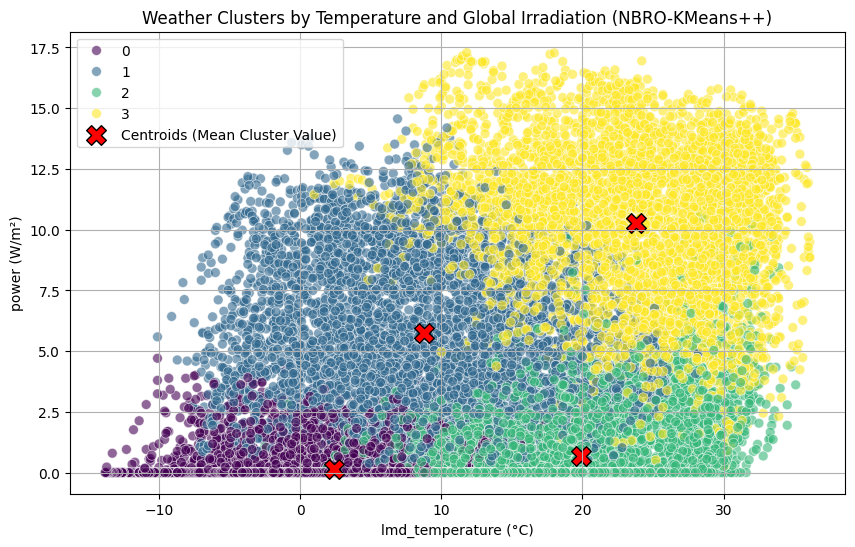

In [19]:
# Add this code snippet to the end of your existing script to generate a plot:

import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns used for plotting
PLOT_FEATURE_X = 'lmd_temperature'
PLOT_FEATURE_Y = 'power'
CLUSTER_COL = 'Cluster_Label'

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_results, 
    x=PLOT_FEATURE_X, 
    y=PLOT_FEATURE_Y, 
    hue=CLUSTER_COL, # Color by cluster label
    palette='viridis', 
    s=50,
    alpha=0.6
)

# Plot the centroids on top
# You need the original scale centroids data calculated previously in centroids_df
plt.scatter(
    centroids_df[PLOT_FEATURE_X], 
    centroids_df[PLOT_FEATURE_Y], 
    marker='X', 
    s=200, 
    c='red', 
    edgecolor='black',
    label='Centroids (Mean Cluster Value)'
)

plt.title('Weather Clusters by Temperature and Global Irradiation (NBRO-KMeans++)')
plt.xlabel(f'{PLOT_FEATURE_X} (°C)')
plt.ylabel(f'{PLOT_FEATURE_Y} (W/m²)')
plt.legend()
plt.grid(True)
plt.show()


### SMOTE

In [21]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# --- Recreate df_results and X_scaled from previous steps if necessary ---
# (Assumes df_results exists with 'Cluster_Label' and feature columns)

# 1. Identify Minority Classes (Optional step for clarity)
print("Original Data Points per Cluster:")
print(df_results['Cluster_Label'].value_counts())
# Your output was:
# Cluster_Label
# 0    13109 (Majority)
# 2    10077 
# 1     4980 (Minority)
# 3     4762 (Minority)

# 2. Prepare Data for SMOTE
# SMOTE requires numerical features (X) and labels (y)
X = df_results.drop('Cluster_Label', axis=1)
y = df_results['Cluster_Label']

# CRITICAL: SMOTE should be applied AFTER standardization to work correctly
# Re-apply standardization if X is not already scaled
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply SMOTE to balance the classes
# We use 'not majority' strategy to oversample all classes except the most frequent one (Cluster 0)
sm = SMOTE(sampling_strategy='not majority', random_state=42, k_neighbors=5)

X_res, y_res = sm.fit_resample(X_scaled, y)

# X_res is a numpy array of scaled, balanced features
# y_res is a numpy array of balanced labels

# 4. Convert the balanced data back into a DataFrame (optional, but useful for analysis)
X_res_original_scale = scaler.inverse_transform(X_res)
df_balanced = pd.DataFrame(X_res_original_scale, columns=X.columns)
df_balanced['Cluster_Label'] = y_res

print("\nBalanced Data Points per Cluster:")
print(df_balanced['Cluster_Label'].value_counts())


Original Data Points per Cluster:
Cluster_Label
0    13109
2    10077
1     4980
3     4762
Name: count, dtype: int64

Balanced Data Points per Cluster:
Cluster_Label
2    13109
3    13109
1    13109
0    13109
Name: count, dtype: int64


In [23]:
df_results

,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,nwp_windspeed,nwp_pressure,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,lmd_pressure,lmd_windspeed,power,P_CLR,K_PV,Cluster_Label
date_time,,,,,,,,,,,,,,,
2018-06-30 16:00:00,0.0,0.0,19.86,61.42,3.49,930.57,0,0,17.600000,934.799988,0.0,0.0,0.0,0.0,2
2018-06-30 16:15:00,0.0,0.0,19.81,61.22,3.51,930.51,0,0,17.500000,934.700012,0.0,0.0,0.0,0.0,2
2018-06-30 16:30:00,0.0,0.0,19.76,61.03,3.52,930.55,0,0,17.299999,934.599976,0.0,0.0,0.0,0.0,2
2018-06-30 16:45:00,0.0,0.0,19.70,60.91,3.53,930.47,0,0,17.200001,934.599976,0.0,0.0,0.0,0.0,2
2018-06-30 17:00:00,0.0,0.0,19.60,60.89,3.51,930.19,0,0,17.100000,934.599976,0.0,0.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-06-13 14:45:00,0.0,0.0,20.58,66.40,3.89,931.33,15,0,17.900000,935.599976,0.0,0.0,0.0,0.0,2
2019-06-13 15:00:00,0.0,0.0,20.58,65.52,3.89,931.40,15,0,17.400000,935.599976,0.9,0.0,0.0,0.0,2
2019-06-13 15:15:00,0.0,0.0,20.50,65.29,3.93,931.49,18,0,17.200001,935.500000,0.0,0.0,0.0,0.0,2


In [22]:
df_balanced

,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,nwp_windspeed,nwp_pressure,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,lmd_pressure,lmd_windspeed,power,P_CLR,K_PV,Cluster_Label
0,0.000000,0.000000,19.860000,61.420000,3.490000,930.570000,0.000000,0.000000,17.600000,934.799988,0.000000,0.000000,0.000000,0.000000,2
1,0.000000,0.000000,19.810000,61.220000,3.510000,930.510000,0.000000,0.000000,17.500000,934.700012,0.000000,0.000000,0.000000,0.000000,2
2,0.000000,0.000000,19.760000,61.030000,3.520000,930.550000,0.000000,0.000000,17.299999,934.599976,0.000000,0.000000,0.000000,0.000000,2
3,0.000000,0.000000,19.700000,60.910000,3.530000,930.470000,0.000000,0.000000,17.200001,934.599976,0.000000,0.000000,0.000000,0.000000,2
4,0.000000,0.000000,19.600000,60.890000,3.510000,930.190000,0.000000,0.000000,17.100000,934.599976,0.000000,0.000000,0.000000,0.000000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52431,599.893903,553.885338,32.600000,26.017210,5.831689,926.486168,598.018927,227.409572,31.340908,929.900024,3.940907,7.545390,10.379267,0.725847,3
52432,706.984270,656.504315,13.735334,21.067950,2.573126,933.977611,780.221977,125.046429,14.558777,937.247685,0.678935,12.499631,15.722157,0.796181,3
52433,914.970011,861.946326,31.115166,10.277885,5.520964,930.699141,1260.367230,595.178344,31.372393,934.163666,2.063672,14.274283,15.591633,0.915822,3
52434,931.160824,876.848809,20.941148,14.080650,2.963954,940.912449,1265.100759,615.460456,21.043879,944.692083,1.935970,16.039414,16.098496,0.996326,3


------